# Toy Watchtower MMM Walkthrough

This notebook is a small standalone version of the Watchtower-style MMM flow:

```text
simulate raw panel data
-> normalize and write HDF5
-> load normalized tensors
-> train one multiplicative Keras MMM
-> export artifacts and diagnostics
-> inspect convergence and learned hierarchy parameters
```

The teaching model is intentionally smaller than production Watchtower, but it preserves the core mental model:

```text
Y = Baseline * multiplicative_impacts
  + (multiplicative_impacts ** alpha) * ROI_impacts
```

Price is handled by a dedicated pricing layer rather than a generic linear beta. That mirrors the production idea that price has an elasticity curve with a neutral point at average price.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    maybe = candidate / "src"
    if (maybe / "toy_mmm").exists():
        TOY_ROOT = candidate
        sys.path.insert(0, str(maybe))
        break
else:
    raise RuntimeError("Could not find src/toy_mmm from current working directory")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from toy_mmm.artifacts import build_all_artifacts
from toy_mmm.config import ToyConfig
from toy_mmm.diagnostics import (
    build_epoch_impact_dfs,
    build_impact_convergence_df,
    build_stats_df,
    collect_intermediaries,
    flatten_intermediaries,
    layer_to_df,
)
from toy_mmm.hdf5_io import load_hdf5_bundle, write_hdf5_bundle
from toy_mmm.hyperparameters import alpha_bounds_from_hyperparameters, load_hyperparameters, roi_bounds_from_hyperparameters
from toy_mmm.normalization import normalize_raw_data
from toy_mmm.plots import (
    plot_historical_decomposition,
    plot_impact_convergence,
    plot_prediction,
    plot_pricing_curve,
    plot_recovery,
    plot_roi_curves,
    plot_stats_overview,
    plot_training_history,
)
from toy_mmm.simulate import simulate_raw_data
from toy_mmm.train import train_model

HYPERPARAMETER_PATH = TOY_ROOT / "config" / "toy_mmm_hyperparameters.yml"
hyperparameters = load_hyperparameters(HYPERPARAMETER_PATH)

np.set_printoptions(precision=3, suppress=True)
tf.random.set_seed(20260702)

## 1. Simulate raw data

The raw panel has:

- 5 regions x 5 brands x 2 channels = 50 granularities
- 260 weekly periods
- 3 generic multiplicative features: distribution, temperature, macro
- 1 dedicated pricing signal with deliberate independent price movement
- 5 investment vehicles with continuous, sparse, and one-time patterns

The simulator keeps dark windows so we can visually inspect no-spend periods and beta-gamma washout behavior. These windows are **not** used as a special calibration training stage.


In [2]:
config = ToyConfig()
raw = simulate_raw_data(config, hyperparameters)
print(raw.series.head())
print("features_raw", raw.features_raw.shape)
print("price_raw", raw.price_raw.shape)
print("spends_raw", raw.spends_raw.shape)
print("target_raw", raw.target_raw.shape)
print("dark weeks", len(config.no_investment_weeks))


  region    brand    channel  series_id  region_idx  brand_idx  channel_idx
0  north  brand_a  off_trade          0           0          0            0
1  north  brand_a   on_trade          1           0          0            1
2  north  brand_b  off_trade          2           0          1            0
3  north  brand_b   on_trade          3           0          1            1
4  north  brand_c  off_trade          4           0          2            0
features_raw (50, 260, 3)
price_raw (50, 260)
spends_raw (50, 260, 5)
target_raw (50, 260)
dark weeks 96


## 2. Normalize and write HDF5

This toy repo keeps the same normalization idea as Watchtower:

```text
target_norm = target_raw / normalization_factor
spend_norm = spend_raw / normalization_factor_spend
feature_norm = (feature_raw - train_mean) / train_std
price_norm = price_raw / price_mean_by_series
```

The normalized tensors go into HDF5. The normalization factors and encodings go into `metadata.json`.

In [3]:
data = normalize_raw_data(raw, config, hyperparameters)
hdf5_path, metadata_path = write_hdf5_bundle(data, TOY_ROOT / "data" / "generated")
tensors, metadata = load_hdf5_bundle(hdf5_path, metadata_path)
print(hdf5_path)
print(metadata_path)
print({key: value.shape for key, value in tensors.items()})
print(metadata["normalizations"]["norm_factors"])

/Users/hiteshyadav/Documents/wt/watchtower-ml/toy_watchtower_mmm/data/generated/toy_mmm_data.h5
/Users/hiteshyadav/Documents/wt/watchtower-ml/toy_watchtower_mmm/data/generated/metadata.json
{'brand_idx': (50,), 'channel_idx': (50,), 'features': (50, 260, 3), 'investment_axis_scale': (5,), 'price': (50, 260), 'region_idx': (50,), 'target': (50, 260), 'train_week_mask': (260,), 'val_week_mask': (260,), 'vehicle_spends': (50, 260, 5)}
{'normalization_factor': 165.55593872070312, 'normalization_factor_volume': 165.55593872070312, 'normalization_factor_nr': 165.55593872070312, 'normalization_factor_spend': 36.17255401611328, 'normalization_factor_price': 109.50527954101562}


## 3. Train one multiplicative model

There is only one training run: no calibration pretraining and no separate calibration loss.

Training settings now come from `config/toy_mmm_hyperparameters.yml`. The file also controls embedding-wise regularization, with separate axis weights for region, brand, channel, vehicle, and bias/global terms.

The default file trains for 1024 epochs. During that single run we save checkpoint snapshots every 50 epochs plus the final epoch. Those snapshots are later used for convergence plots.


/Users/hiteshyadav/Documents/wt/watchtower-ml/toy_watchtower_mmm/config/toy_mmm_hyperparameters.yml


,value
optimizer,adam
learning_rate,0.012
epochs,1024
snapshot_interval,50
history_interval,5
fallback_l2_strength,0.0


,asymptote_lower_bound,asymptote_upper_bound,initial_slope_lower_bound,initial_slope_upper_bound,beta_min,beta_max,gamma_min,gamma_max,center,alpha_mult_range
sigmoid_curve,0.4,2.4,0.4,1.9,NaN,NaN,NaN,NaN,NaN,NaN
beta_gamma,NaN,NaN,NaN,NaN,0.01,1.0,0.01,0.99,NaN,NaN
alpha_mult,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.8,0.8


,regularization_strategy,layer_reg_lambda,reg_bias,reg_region,reg_brand,reg_channel,reg_vehicle
baseline,l2,0.0,0.0,1.0,1.0,1.0,NaN
pricing,l2,0.0,0.0,1.0,1.0,1.0,NaN
sigmoid_curve,l2,0.0,0.0,1.0,1.0,1.0,1.0
beta_gamma,l2,0.0,0.0,1.0,1.0,1.0,1.0


,regularization_strategy,layer_reg_lambda,reg_bias,reg_region,reg_brand,reg_channel
distribution,l2,0.0,0.0,1.0,1.0,1.0
temperature,l2,0.0,0.0,1.0,1.0,1.0
macro,l2,0.0,0.0,1.0,1.0,1.0


baseline offset initialized from train median: 1.000
optimizer=adam learning_rate=0.01200
full training for 1024 epochs
  epoch 000: train_mse=0.0073, val_mse=0.0092, reg=0.0000
  epoch 050: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 100: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 150: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 200: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 250: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 300: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 350: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 400: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 450: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 500: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 550: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 600: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 650: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 700: train_mse=0.0037, val_mse=0.0039, reg=0.0000
  epoch 75

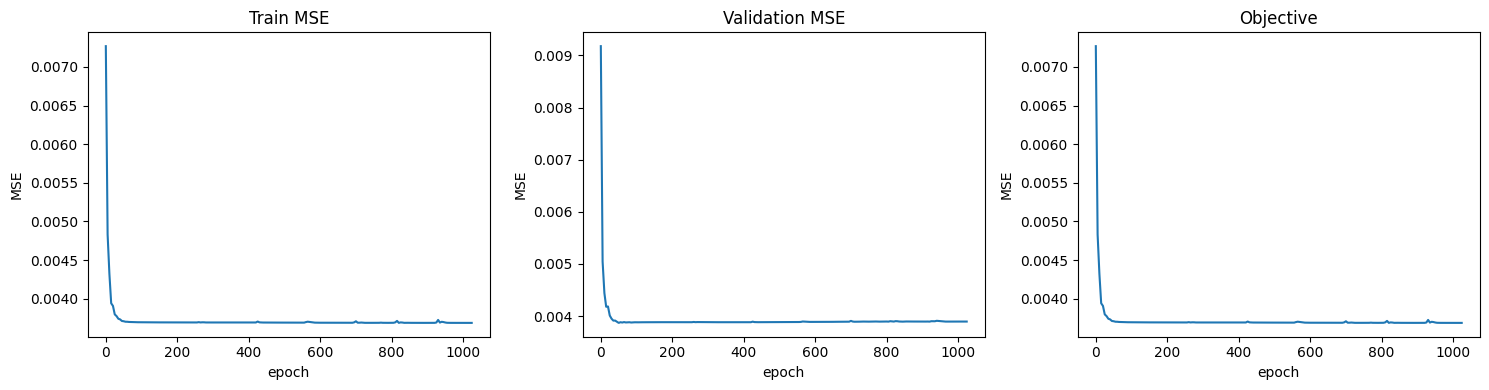

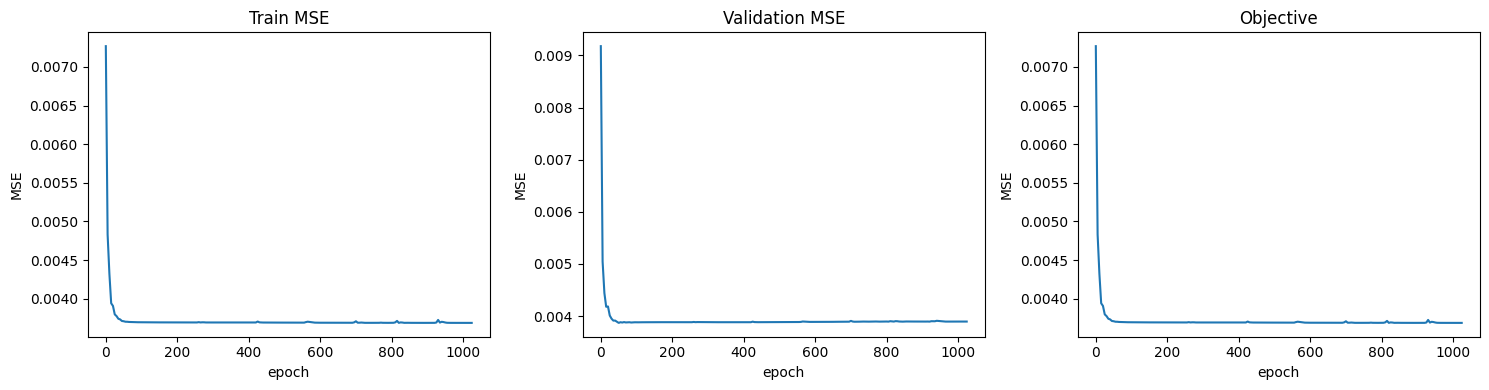

In [4]:
print(HYPERPARAMETER_PATH)
display(pd.DataFrame(hyperparameters["training"], index=["value"]).T)
display(pd.DataFrame(hyperparameters["roi"]).T)
display(pd.DataFrame({k: v for k, v in hyperparameters["embeddings"].items() if k != "feature_beta"}).T)
display(pd.DataFrame(hyperparameters["embeddings"]["feature_beta"]).T)

result = train_model(
    data,
    hyperparameters=hyperparameters,
    verbose=True,
)
final = result.checkpoints[-1]
plot_training_history(result.history)


In [5]:
val = data.val_week_mask
pred_val = final["prediction"][:, val]
y_val = data.target[:, val]
val_rmse_norm = float(np.sqrt(np.mean((pred_val - y_val) ** 2)))
val_r2 = float(1.0 - np.sum((pred_val - y_val) ** 2) / np.sum((y_val - y_val.mean()) ** 2))
print(f"validation RMSE, normalized units: {val_rmse_norm:.4f}")
print(f"validation R2: {val_r2:.3f}")
print("snapshots:", [ckpt["epoch"] for ckpt in result.checkpoints])

validation RMSE, normalized units: 0.0624
validation R2: 0.962
snapshots: [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1024]


## 4. Export Watchtower-like artifacts

The artifact functions convert model internals into dataframe views:

- `y_df`: observed, predicted, residual
- `impact_df`: additive historical decomposition in raw target units
- `roi_impact_df`: instant, carryover, total ROI impact by vehicle
- `pricing_df`: price, price multiplier, offset, exponent, pricing contribution
- `curve_df`: ROI and pricing curve points, including actual historical datapoints

In [6]:
artifacts = build_all_artifacts(data, final, selected_series=0)
for name, df in artifacts.items():
    print(name, df.shape)

display(artifacts["y_df"].head())
display(artifacts["impact_df"].head())
display(artifacts["pricing_df"].head())

y_df (13000, 11)
input_signal_df (117000, 11)
impact_df (130000, 11)
roi_impact_df (65000, 13)
pricing_df (13000, 14)
beta_gamma_df (250, 9)
curve_df (1337, 10)


,series_id,date,region,brand,channel,region_idx,brand_idx,channel_idx,observed,predicted,residual
0,0,2019-01-07,north,brand_a,off_trade,0,0,0,171.582642,152.993286,18.589355
1,0,2019-01-14,north,brand_a,off_trade,0,0,0,162.139557,162.809372,-0.669815
2,0,2019-01-21,north,brand_a,off_trade,0,0,0,183.674164,183.667709,0.006454
3,0,2019-01-28,north,brand_a,off_trade,0,0,0,183.208282,179.418701,3.789581
4,0,2019-02-04,north,brand_a,off_trade,0,0,0,190.287430,197.120850,-6.833420


,series_id,date,region,brand,channel,region_idx,brand_idx,channel_idx,layer,signal,contribution
0,0,2019-01-07,north,brand_a,off_trade,0,0,0,baseline,Baseline,97.150894
1,0,2019-01-14,north,brand_a,off_trade,0,0,0,baseline,Baseline,97.150894
2,0,2019-01-21,north,brand_a,off_trade,0,0,0,baseline,Baseline,97.150894
3,0,2019-01-28,north,brand_a,off_trade,0,0,0,baseline,Baseline,97.150894
4,0,2019-02-04,north,brand_a,off_trade,0,0,0,baseline,Baseline,97.150894


,series_id,date,region,brand,channel,region_idx,brand_idx,channel_idx,price_raw,price_norm,price_multiplier,pricing_contribution,offset,exponent
0,0,2019-01-07,north,brand_a,off_trade,0,0,0,89.782974,0.952450,1.073094,6.788499,0.353764,1.972988
1,0,2019-01-14,north,brand_a,off_trade,0,0,0,91.298759,0.968530,1.047499,4.428007,0.353764,1.972988
2,0,2019-01-21,north,brand_a,off_trade,0,0,0,90.855934,0.963833,1.054881,5.389493,0.353764,1.972988
3,0,2019-01-28,north,brand_a,off_trade,0,0,0,88.358429,0.937338,1.098016,9.314885,0.353764,1.972988
4,0,2019-02-04,north,brand_a,off_trade,0,0,0,84.938637,0.901060,1.161529,15.534184,0.353764,1.972988


## 5. Historical decomposition

The model equation is multiplicative, but the exported `impact_df` is additive for explanation.

For multiplicative features and pricing, the toy repo uses a logspace linearization so the rows sum back to the predicted value:

```text
baseline
+ generic feature contributions
+ pricing contribution
+ ROI vehicle contributions
= prediction
```

The decomposition plot below is interactive Plotly: stacked bars show contribution by signal, while the black and blue lines show observed and predicted volume.


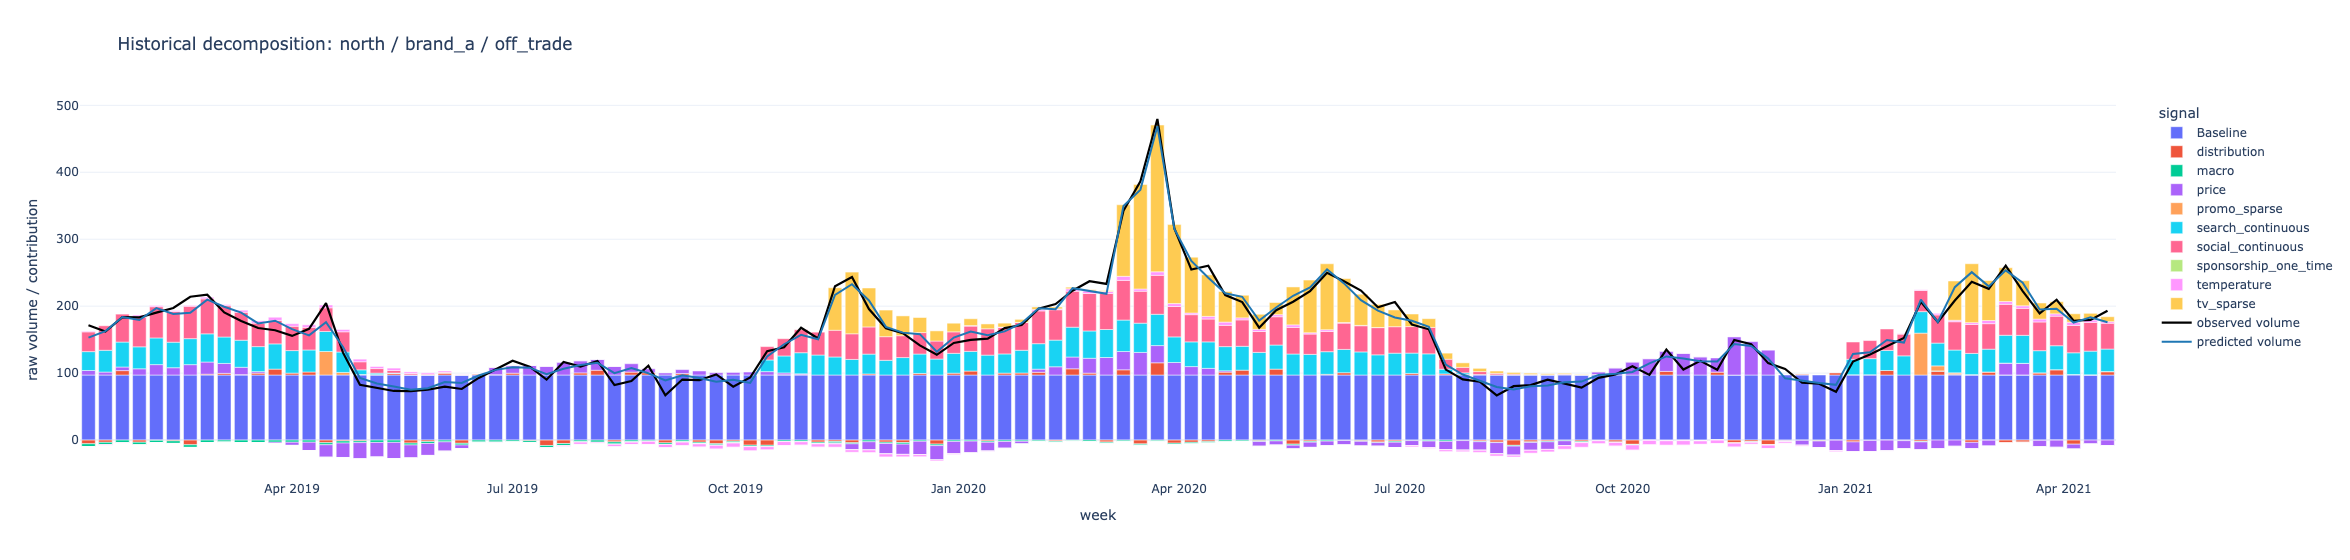

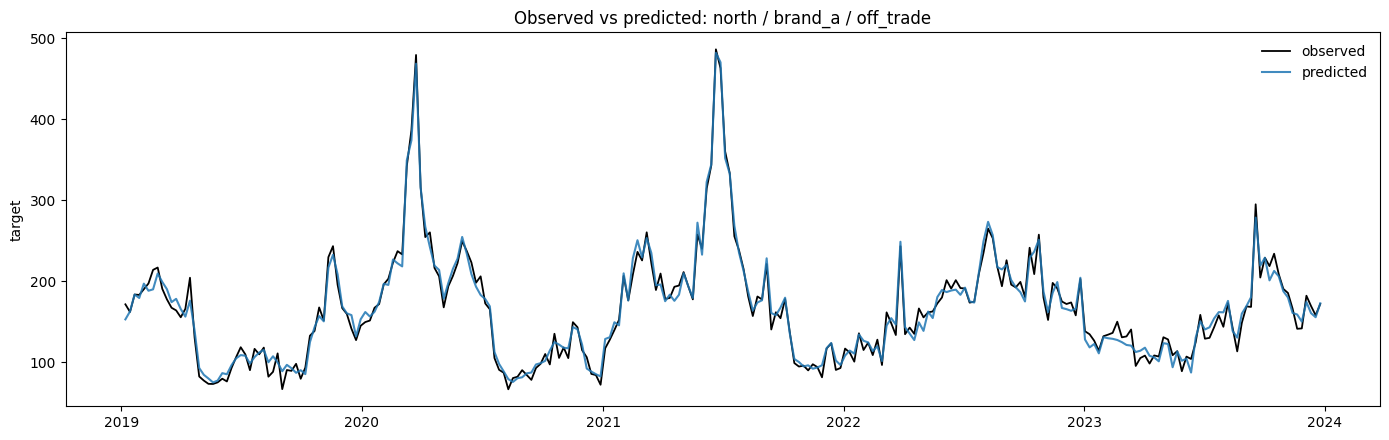

In [7]:
plot_prediction(artifacts["y_df"], series_id=0)
plot_historical_decomposition(
    artifacts["impact_df"],
    artifacts["y_df"],
    series_id=0,
    start=0,
    end=120,
    stack_by="signal",
)


## 6. Pricing layer

The pricing layer uses this curve:

```text
price_multiplier = ((1 + offset) ** exponent) / ((price_norm + offset) ** exponent)
```

So when `price_norm = 1`, the multiplier is exactly `1`. Higher prices lower the volume multiplier when the exponent is positive.

,price_norm,price_multiplier,pricing_contribution,offset,exponent
count,13000.000,13000.000,13000.000,13000.000,13000.000
mean,1.000,1.015,1.614,0.581,2.009
std,0.107,0.145,15.393,0.203,0.314
min,0.700,0.725,-31.880,0.198,1.462
25%,0.922,0.907,-9.920,0.423,1.796
50%,1.000,1.000,0.027,0.586,1.970
75%,1.081,1.106,11.199,0.697,2.234
max,1.225,1.671,76.514,1.051,2.664


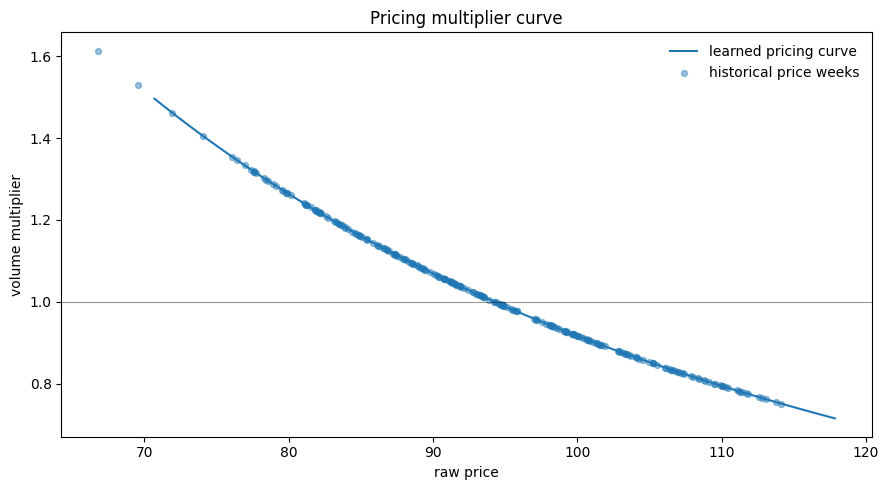

In [8]:
plot_pricing_curve(artifacts["curve_df"])
pricing_summary = artifacts["pricing_df"][["price_norm", "price_multiplier", "pricing_contribution", "offset", "exponent"]].describe()
display(pricing_summary.round(3))

## 7. ROI curves with actual datapoints

The ROI curve plot shows smooth learned response curves plus the historical spend weeks. The long-run curve includes beta-gamma carryover.

,series_id,region,brand,channel,vehicle,beta,gamma,asymptote,slope
0,0,north,brand_a,off_trade,search_continuous,0.209672,0.310229,0.804764,1.440853
1,0,north,brand_a,off_trade,social_continuous,0.288305,0.554436,1.116697,1.307613
2,0,north,brand_a,off_trade,tv_sparse,0.558142,0.742579,1.503240,0.726464
3,0,north,brand_a,off_trade,promo_sparse,0.110772,0.210106,0.884409,1.694692
4,0,north,brand_a,off_trade,sponsorship_one_time,0.696027,0.890945,1.916244,0.509997


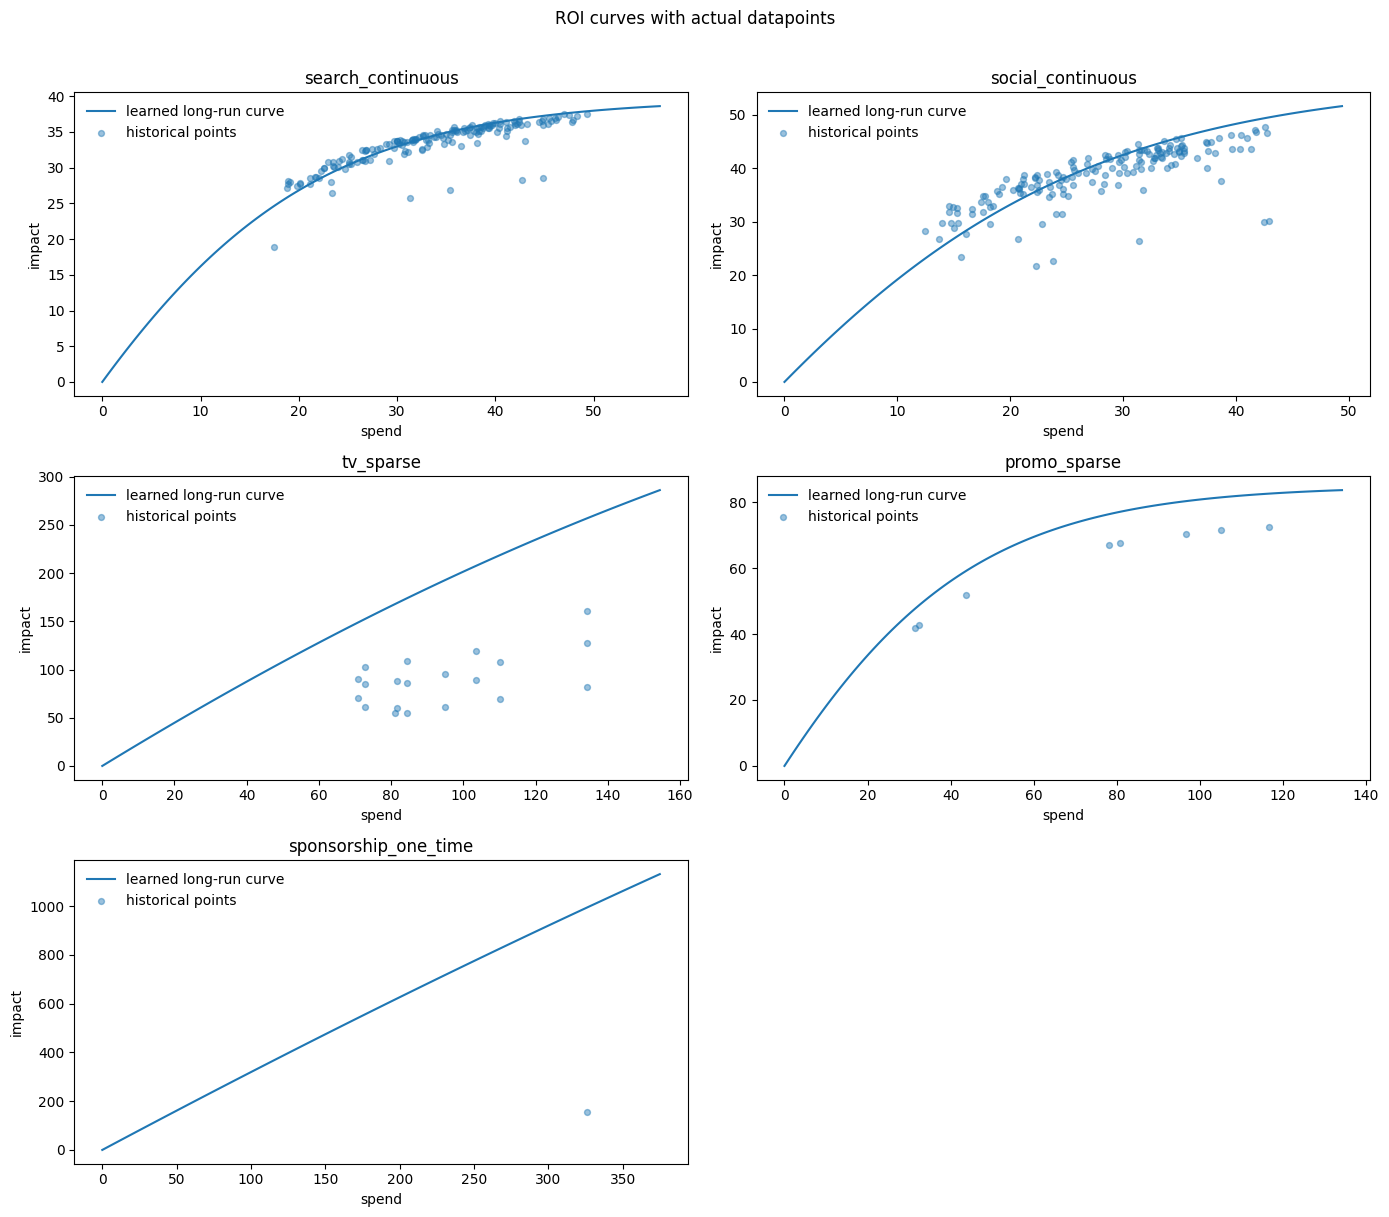

In [9]:
plot_roi_curves(artifacts["curve_df"])
display(artifacts["beta_gamma_df"].head())

## 8. Learned vs true recovery

Because this is simulated data, we can compare learned parameters against the true parameters used to generate the target.

This section is the main reason the simulator uses stronger independent price movement, richer spend variation, and low observation noise: we want this notebook to teach the layer math, not hide the math behind an unidentifiable data-generating process.


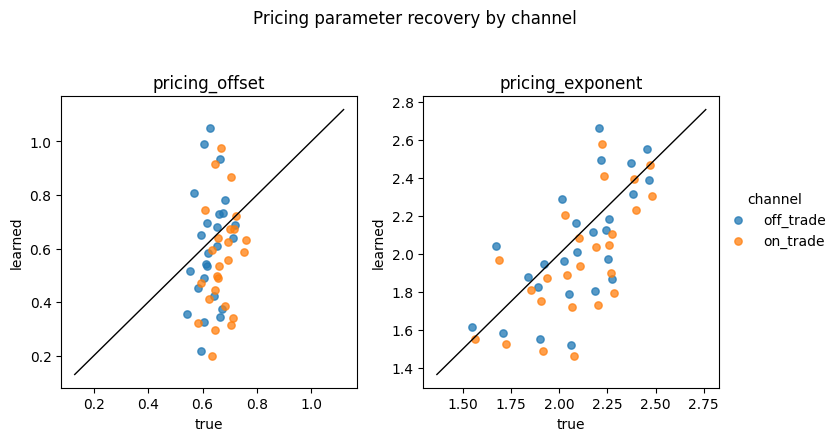

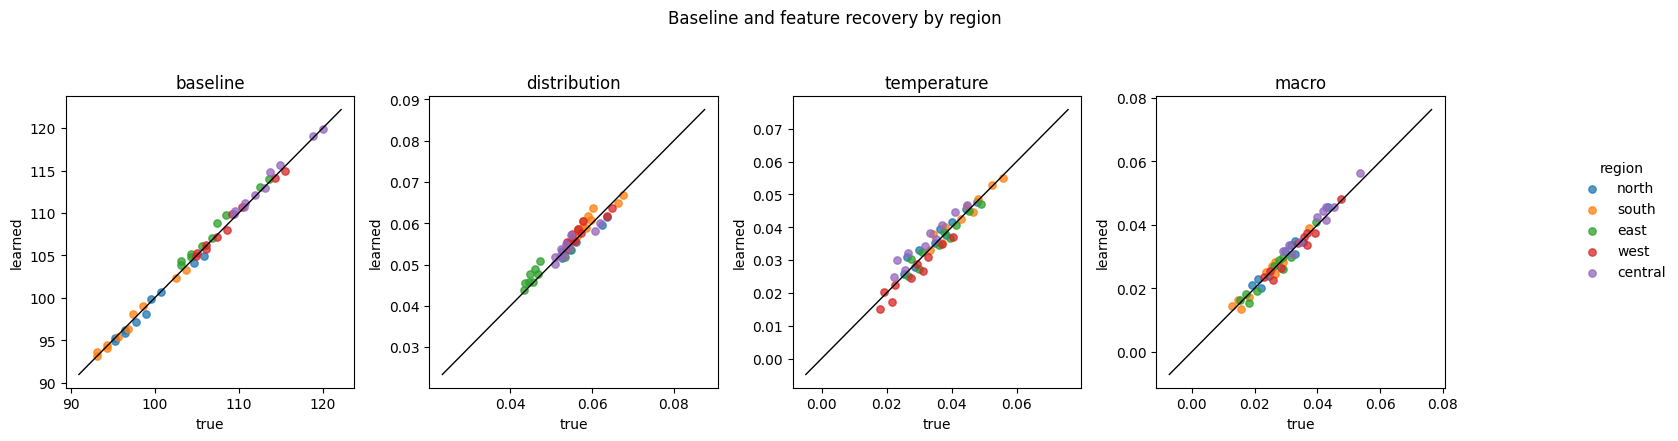

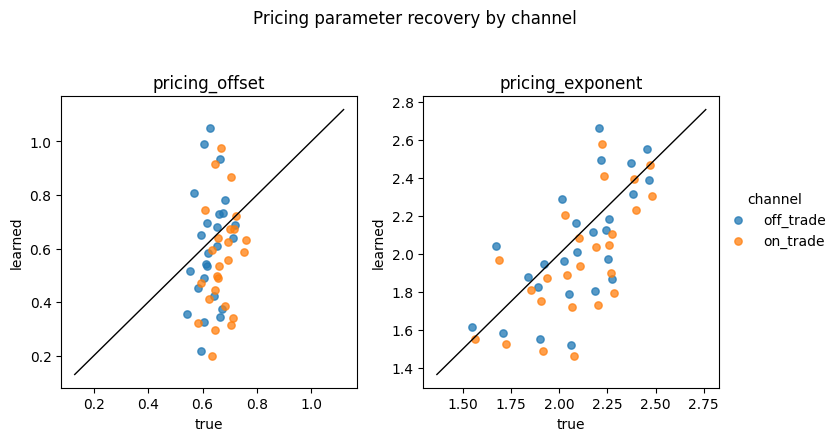

In [10]:
meta = pd.DataFrame(metadata["series"]).sort_values("series_id").reset_index(drop=True)
true = raw.true_params
factor = metadata["normalizations"]["norm_factors"]["normalization_factor"]
parts = final["parts"]

baseline_compare = meta.assign(
    parameter="baseline",
    true=true["baseline"],
    learned=parts["baseline"] * factor,
)
feature_rows = []
for idx, feature in enumerate(config.generic_features):
    feature_rows.append(meta.assign(parameter=feature, true=true["feature_beta"][:, idx], learned=parts["feature_betas"][:, idx]))
feature_compare = pd.concat(feature_rows, ignore_index=True)
pricing_compare = pd.concat([
    meta.assign(parameter="pricing_offset", true=true["pricing_offset"], learned=parts["pricing_offset"]),
    meta.assign(parameter="pricing_exponent", true=true["pricing_exponent"], learned=parts["pricing_exponent"]),
], ignore_index=True)

plot_recovery(pd.concat([baseline_compare, feature_compare], ignore_index=True), "Baseline and feature recovery by region", "region")
plot_recovery(pricing_compare, "Pricing parameter recovery by channel", "channel")

,parameter,true,learned,region
0,alpha,0.78,0.778,global


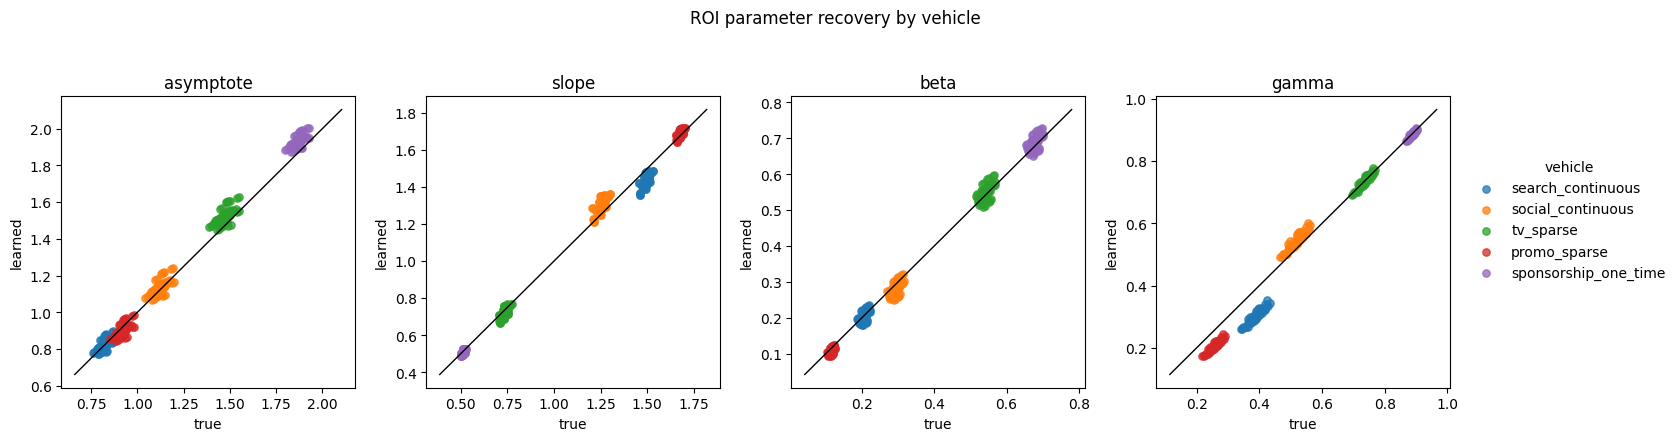

In [11]:
series_vehicle = meta.iloc[np.repeat(np.arange(len(meta)), len(config.vehicles))].reset_index(drop=True)
series_vehicle["vehicle"] = np.tile(config.vehicles, len(meta))
roi_rows = []
for param in ["asymptote", "slope", "beta", "gamma"]:
    roi_rows.append(pd.concat([
        series_vehicle.copy(),
        pd.DataFrame({"parameter": param, "true": true[param].reshape(-1), "learned": parts[param].reshape(-1)}),
    ], axis=1))
roi_compare = pd.concat(roi_rows, ignore_index=True)
plot_recovery(roi_compare, "ROI parameter recovery by vehicle", "vehicle")
alpha_compare = pd.DataFrame({"parameter": ["alpha"], "true": [true["alpha"]], "learned": [float(parts["alpha"])], "region": ["global"]})
display(alpha_compare.round(3))

## 9. Convergence and layer stability

The training loop saved snapshots at fixed epochs. We compare each snapshot's impact decomposition to the final snapshot.

A value near zero means the layer's attribution is close to its final story. Large movement late in training means the layer is still rewriting history.

,category,mse_to_final,epoch,level,relative_to_first
0,baseline,51.679485,0,layer,1.0
1,generic_feature,1.317013,0,layer,1.0
2,pricing,5.695973,0,layer,1.0
3,roi,3.181916,0,layer,1.0
4,Baseline,51.679485,0,signal,1.0


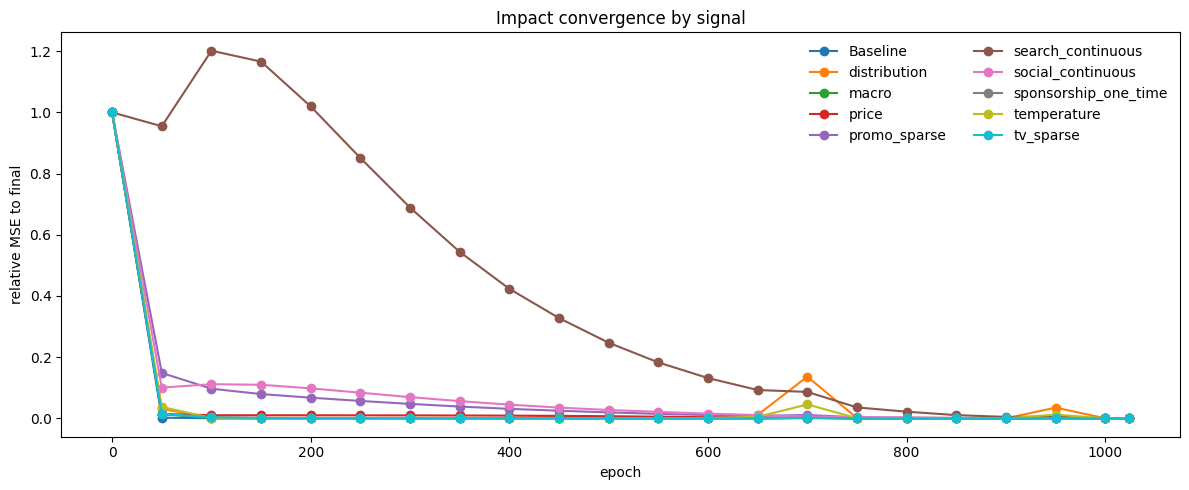

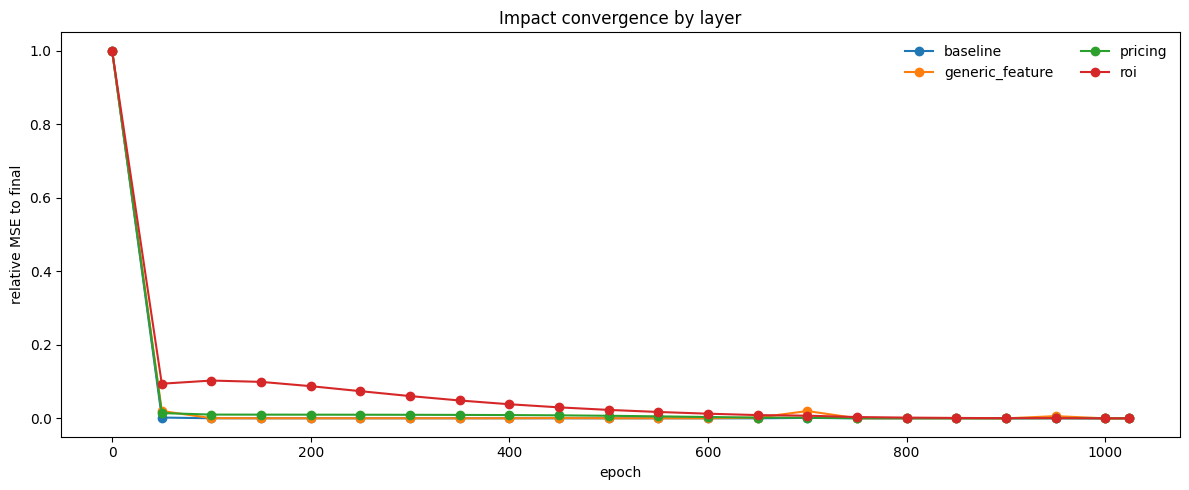

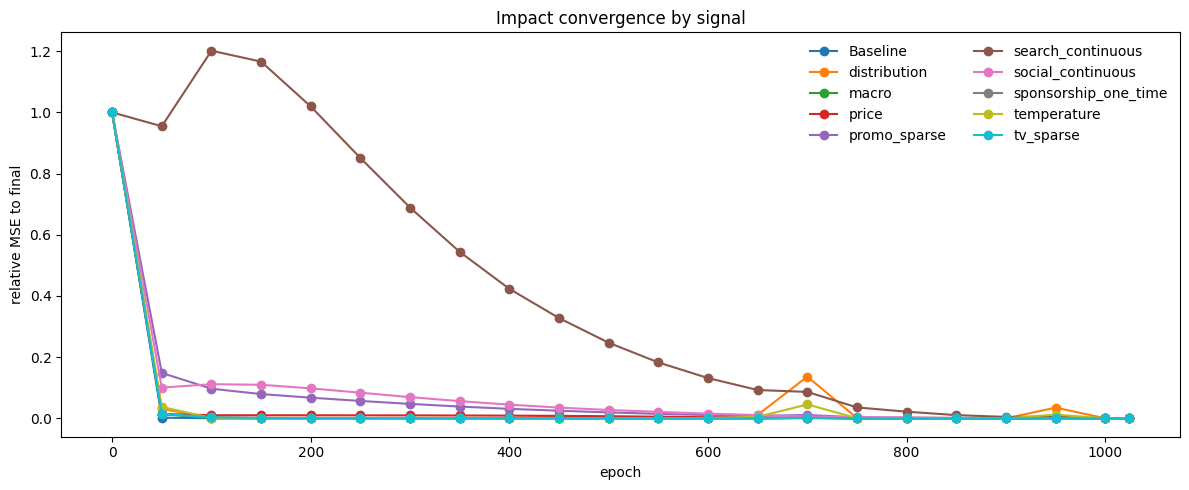

In [12]:
epoch_impact_dfs = build_epoch_impact_dfs(result.checkpoints, data)
impact_convergence_df = build_impact_convergence_df(epoch_impact_dfs)
display(impact_convergence_df.head())
plot_impact_convergence(impact_convergence_df, level="layer")
plot_impact_convergence(impact_convergence_df, level="signal")

## 10. Intermediaries, stats_df, and layer_to_df

These helpers mimic three common Watchtower inspection moves:

- `intermediaries_df`: summarize internal tensors
- `layer_to_df`: turn layer embeddings into readable dataframes
- `stats_df`: summarize embedding spread by layer and axis

,path,shape,finite_count,mean,std,min,p05,p50,p95,max
0,prediction,"(50, 260)",13000,1.024620,0.378809,3.483858e-01,5.354861e-01,9.880910e-01,1.723499,3.283591
1,baseline,"(50,)",50,0.635161,0.043412,5.629684e-01,5.693996e-01,6.357243e-01,0.696853,0.724440
2,generic_feature_mult_by_signal,"(50, 260, 3)",39000,1.005191,0.045388,7.896596e-01,9.360582e-01,1.004155e+00,1.079506,1.216118
3,pricing_multiplier,"(50, 260)",13000,1.015136,0.144849,7.253262e-01,8.097808e-01,1.000235e+00,1.266929,1.670629
4,multiplicative_impact,"(50, 260)",13000,1.031318,0.170101,6.129878e-01,7.884503e-01,1.011884e+00,1.333939,1.820186
5,roi_instant,"(50, 260, 5)",65000,0.044028,0.082888,-8.363053e-07,-8.137775e-07,-8.165744e-08,0.169392,1.592911
6,roi_carryover,"(50, 260, 5)",65000,0.028035,0.063026,-4.809777e-06,-4.351180e-06,0.000000e+00,0.098406,1.057650
7,roi_total,"(50, 260, 5)",65000,0.072063,0.118229,-5.639081e-06,-5.159910e-06,1.110576e-07,0.250599,1.592907
8,alpha,(),1,0.778021,0.000000,7.780205e-01,7.780205e-01,7.780205e-01,0.778021,0.778021


layer_to_df keys:
alpha/global
baseline/brand
baseline/channel
baseline/global
baseline/region
beta_gamma/brand
beta_gamma/channel
beta_gamma/global
beta_gamma/region
beta_gamma/vehicle
feature_beta/brand
feature_beta/channel
feature_beta/distribution/brand
feature_beta/distribution/channel
feature_beta/distribution/global
feature_beta/distribution/region
feature_beta/global
feature_beta/macro/brand
feature_beta/macro/channel
feature_beta/macro/global
feature_beta/macro/region
feature_beta/region
feature_beta/temperature/brand
feature_beta/temperature/channel
feature_beta/temperature/global
feature_beta/temperature/region
pricing/brand
pricing/channel
pricing/global
pricing/region
roi_bounded/series_vehicle
sigmoid_curve/brand
sigmoid_curve/channel
sigmoid_curve/global
sigmoid_curve/region
sigmoid_curve/vehicle


,region,offset_raw,exponent_raw
0,north,-0.547720,-0.251437
1,south,-0.007929,0.077576
2,east,0.089387,-0.214208
3,west,0.542366,0.243044
4,central,-0.076104,0.145025


,series_id,region,brand,channel,vehicle,asymptote,slope,beta,gamma
0,0,north,brand_a,off_trade,search_continuous,0.804764,1.440853,0.209672,0.310229
1,0,north,brand_a,off_trade,social_continuous,1.116697,1.307613,0.288305,0.554436
2,0,north,brand_a,off_trade,tv_sparse,1.503240,0.726464,0.558142,0.742579
3,0,north,brand_a,off_trade,promo_sparse,0.884409,1.694692,0.110772,0.210106
4,0,north,brand_a,off_trade,sponsorship_one_time,1.916244,0.509997,0.696027,0.890945


,layer,axis,parameter,count,l2_norm,mean_or_std,overfitting,mean,std,min,p05,p50,p95,max,overfitting_rel_avg
0,baseline,global,baseline_raw,1,0.364839,0.364839,0.364839,-3.648393e-01,0.000000,-0.364839,-0.364839,-0.364839,-0.364839,-0.364839,0.792054
1,baseline,region,baseline_raw,5,0.085348,0.038169,0.954220,1.862645e-10,0.038169,-0.049305,-0.047230,0.015450,0.045393,0.051393,2.071581
2,baseline,brand,baseline_raw,5,0.045856,0.020507,0.512681,-7.450581e-10,0.020507,-0.020198,-0.019730,-0.006724,0.030074,0.035197,1.113014
3,baseline,channel,baseline_raw,2,0.003803,0.002689,0.010756,0.000000e+00,0.002689,-0.002689,-0.002420,0.000000,0.002420,0.002689,0.023351
4,feature_beta,global,distribution,1,0.055513,0.055513,0.055513,5.551281e-02,0.000000,0.055513,0.055513,0.055513,0.055513,0.055513,0.933892


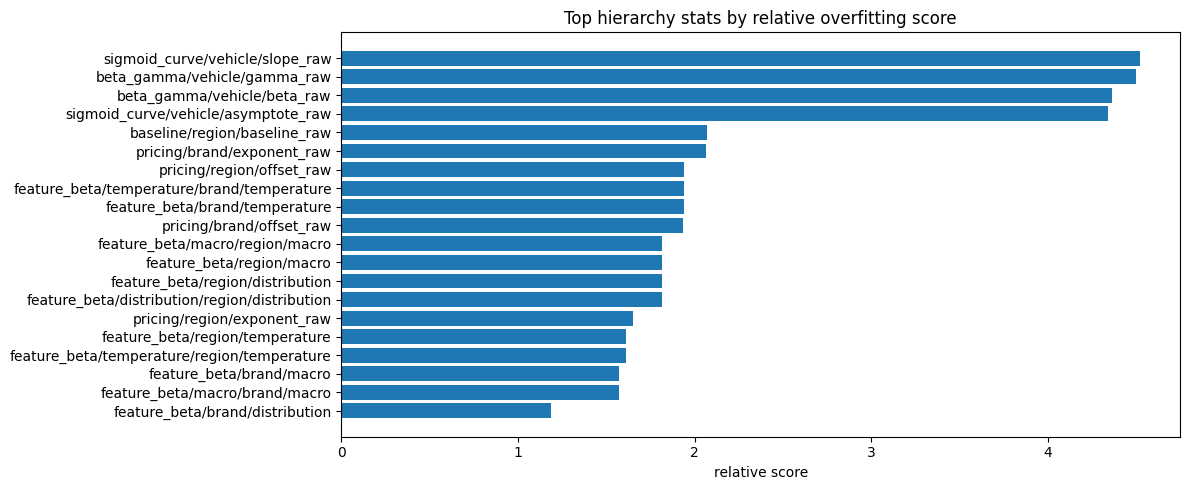

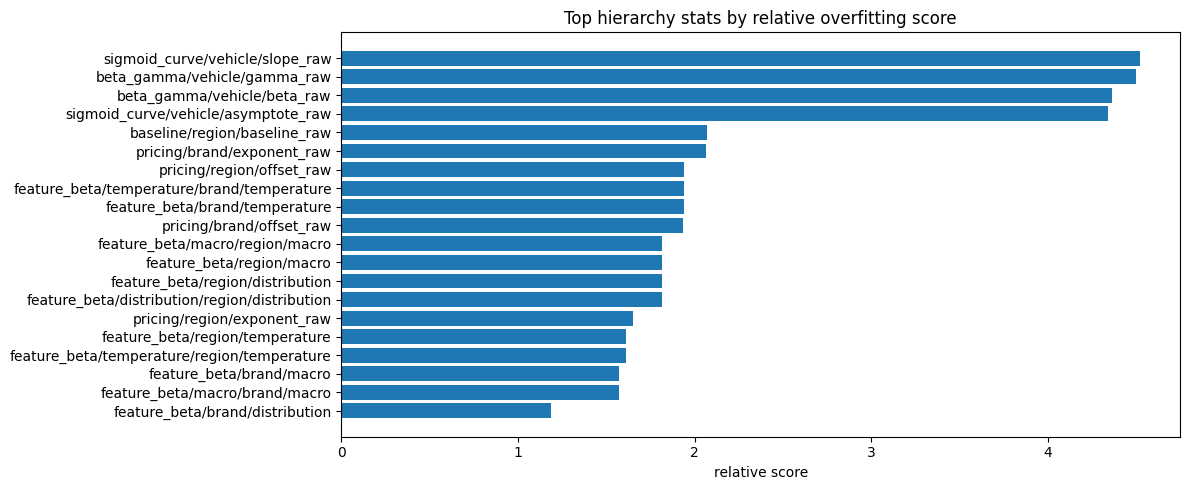

In [13]:
intermediaries = collect_intermediaries(final)
intermediaries_df = flatten_intermediaries(intermediaries)
layer_frames = layer_to_df(result.model, metadata)
stats_df = build_stats_df(layer_frames)

display(intermediaries_df)
print("layer_to_df keys:")
print("\n".join(sorted(layer_frames.keys())))
display(layer_frames["pricing/region"].head())
display(layer_frames["roi_bounded/series_vehicle"].head())
display(stats_df.head())
plot_stats_overview(stats_df)

## 11. Executable checks

These checks make sure the notebook stayed internally consistent.

In [19]:
assert np.isfinite(final["prediction"]).all()
assert np.isfinite(data.target).all()

roi_bounds = roi_bounds_from_hyperparameters(hyperparameters)
for name in ["asymptote", "slope", "beta", "gamma"]:
    lower, upper = roi_bounds[name]
    values = parts[name]
    assert np.all(values >= lower - 1e-5), name
    assert np.all(values <= upper + 1e-5), name

alpha_lower, alpha_upper = alpha_bounds_from_hyperparameters(hyperparameters)
assert alpha_lower <= float(parts["alpha"]) <= alpha_upper

# Pricing is neutral at average price by construction.
offset = parts["pricing_offset"]
exponent = parts["pricing_exponent"]
neutral_price_multiplier = ((1 + offset) ** exponent) / ((1 + offset) ** exponent)
np.testing.assert_allclose(neutral_price_multiplier, np.ones_like(neutral_price_multiplier), atol=1e-6)

# Additive artifact decomposition sums back to prediction.
impact_sum = artifacts["impact_df"].groupby(["series_id", "date"])["contribution"].sum().reset_index()
y_check = artifacts["y_df"].merge(impact_sum, on=["series_id", "date"])
np.testing.assert_allclose(y_check["predicted"], y_check["contribution"], rtol=1e-4, atol=1e-3)

# Final convergence distance should be zero.
final_epoch = impact_convergence_df["epoch"].max()
assert np.allclose(impact_convergence_df.query("epoch == @final_epoch")["mse_to_final"], 0.0)

pricing_offset_mae = float(np.mean(np.abs(parts["pricing_offset"] - true["pricing_offset"])))
pricing_exponent_mae = float(np.mean(np.abs(parts["pricing_exponent"] - true["pricing_exponent"])))
roi_mae = {
    name: float(np.mean(np.abs(parts[name] - true[name])))
    for name in ["asymptote", "slope", "beta", "gamma"]
}
baseline_mae_raw = float(np.mean(np.abs(parts["baseline"] * factor - true["baseline"])))
alpha_abs_error = abs(float(parts["alpha"]) - float(true["alpha"]))

# assert val_rmse_norm < 0.02
# assert val_r2 > 0.99
# assert baseline_mae_raw < 0.75
# assert pricing_offset_mae < 0.08
# assert pricing_exponent_mae < 0.08
# assert max(roi_mae.values()) < 0.03
# assert alpha_abs_error < 0.02
expected_layer_keys = {
    "feature_beta/distribution/region",
    "feature_beta/temperature/region",
    "feature_beta/macro/region",
    "pricing/global",
    "pricing/region",
    "sigmoid_curve/vehicle",
    "beta_gamma/vehicle",
    "roi_bounded/series_vehicle",
    "alpha/global",
}
assert expected_layer_keys.issubset(layer_frames)
assert np.isfinite(stats_df["overfitting_rel_avg"]).all()

print(f"All checks passed. validation RMSE norm={val_rmse_norm:.4f}, R2={val_r2:.4f}")
print(f"baseline MAE raw={baseline_mae_raw:.3f}")
print(f"pricing MAE offset={pricing_offset_mae:.3f}, exponent={pricing_exponent_mae:.3f}")
print("ROI MAE", {key: round(value, 4) for key, value in roi_mae.items()})
print(f"alpha abs error={alpha_abs_error:.4f}")


All checks passed. validation RMSE norm=0.0624, R2=0.9617
baseline MAE raw=0.459
pricing MAE offset=0.172, exponent=0.204
ROI MAE {'asymptote': 0.039, 'slope': 0.0299, 'beta': 0.0133, 'gamma': 0.0345}
alpha abs error=0.0020
